# RadHarmony: A Hands-On Introduction

### The problem RadHarmony solves

Public datasets are each stored differently:

- different folder layouts,
- different file formats (DICOM, PNG, JPEG, NIfTI),
- different label columns in their metadata.

Reading each one normally means writing dataset-specific code before any modeling can begin.

RadHarmony gives you **one consistent interface across roughly 30 datasets**: the code you learn for one applies to all of them. To **harmonize** is to convert differently-organized datasets into one common format, the core job this library does.

## Setup

RadHarmony is installed with [`uv`](https://docs.astral.sh/uv/) (see the README).
The imports below assume it is already available in the environment.

The examples use the **Montgomery County chest X-ray set**: 138 images, roughly
half normal and half tuberculosis-positive. Its small size keeps each step fast.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt

from basepaths import *

import torch
import matplotlib.pyplot as plt

# The only path you ever need to point at: the folder of images.
# MONTGOMERY_DIR = "/mnt/NAS4/datasets/external/Montgomery-CXR/MontgomerySet/CXR_png/"

## 1. Loading a dataset

Each dataset in RadHarmony is a Python class. You provide the location of the
images and specify which outputs you need, then request the data.

In [2]:
from radharmony.dataset import MontgomeryCXRDataset

ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    output_cls=True,  # also return the classification label
)

# get_datasets() returns ready-to-use, PyTorch-ready data. Called with no
# arguments it returns a single dataset over every image.
full_ds = ds.get_datasets()

print(f"Total images: {len(full_ds)}")
print(f"Label(s)    : {MontgomeryCXRDataset.LABEL_COLS}")

Total images: 138
Label(s)    : ['tuberculosis']


`full_ds` behaves like an ordinary Python sequence: it supports `len()` and
indexing. Each item is one sample, a dictionary holding the image under `img`
and, because `output_cls=True`, its label under `cls`. (The train/validation
split comes later, in §6.)

Number of samples: 138
Keys in the sample : ['img', 'cls']
Image shape        : (1, 224, 224)   (channels, height, width)
Image value range  : [-1.00, 1.00]
Label              : [0.0]   (1 = tuberculosis, 0 = no finding)


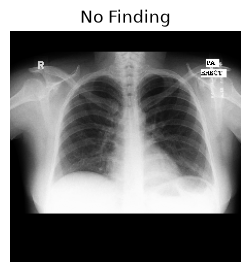

In [3]:
# It has a length ...
print("Number of samples:", len(full_ds))

# ... and supports indexing; each item is one sample dictionary.
sample = full_ds[0]
print("Keys in the sample :", list(sample.keys()))
print("Image shape        :", tuple(sample["img"].shape), "  (channels, height, width)")
print("Image value range  : [%.2f, %.2f]" % (sample["img"].min(), sample["img"].max()))
print(
    "Label              :",
    sample["cls"].tolist(),
    "  (1 = tuberculosis, 0 = no finding)",
)

# And here is that image. squeeze() drops the channel dimension so matplotlib
# can show it as a 2-D grid.
plt.figure(figsize=(3, 3))
plt.imshow(sample["img"].float().squeeze(), cmap="gray")
plt.title("TB" if sample["cls"].item() == 1 else "No Finding")
plt.axis("off")
plt.show()

RadHarmony's built-in viewer `visualize_samples` draws each sample with its label in the title and overlays any enabled outputs (masks, boxes), yielding one matplotlib figure per sample. Choose which samples to show:

- `indices=` : specific samples (here 9, 56, 100)
- `n=` : a random selection
- `per_label=True` : one positive example per label

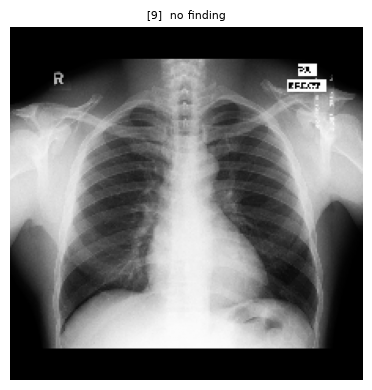

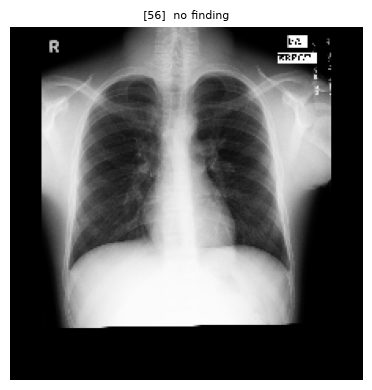

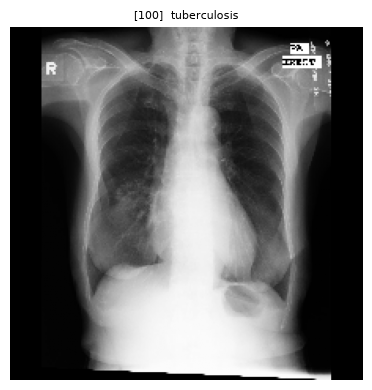

In [4]:
for fig in ds.visualize_samples(full_ds, indices=[9, 56, 100]):
    display(fig)
    plt.close(fig)

## 2. Preprocessing and augmentation

Before an image reaches a model, RadHarmony standardizes it automatically:

1. **Resizing** every image to a uniform 224×224, so images can be batched
   together.
2. **Normalizing** pixel values to roughly −1 to 1, the range models expect.

That is why the sample above is a `(1, 224, 224)` tensor with values near
`[-1, 1]`.

### Customizing preprocessing and augmentation

The two standardizing steps above come from a default transform. `RadiologyTransform2D` lets you build your own: keep the resize and normalize, then layer augmentations with the `.with_*` methods (`with_flip`, `with_affine`, `with_intensity_jitter`, and more). Pass the result as the dataset's `transform=`.

In real training you would augment only the training split (via `get_datasets(train_transform=...)`) and keep validation deterministic; here we apply it to the full dataset to show the effect.

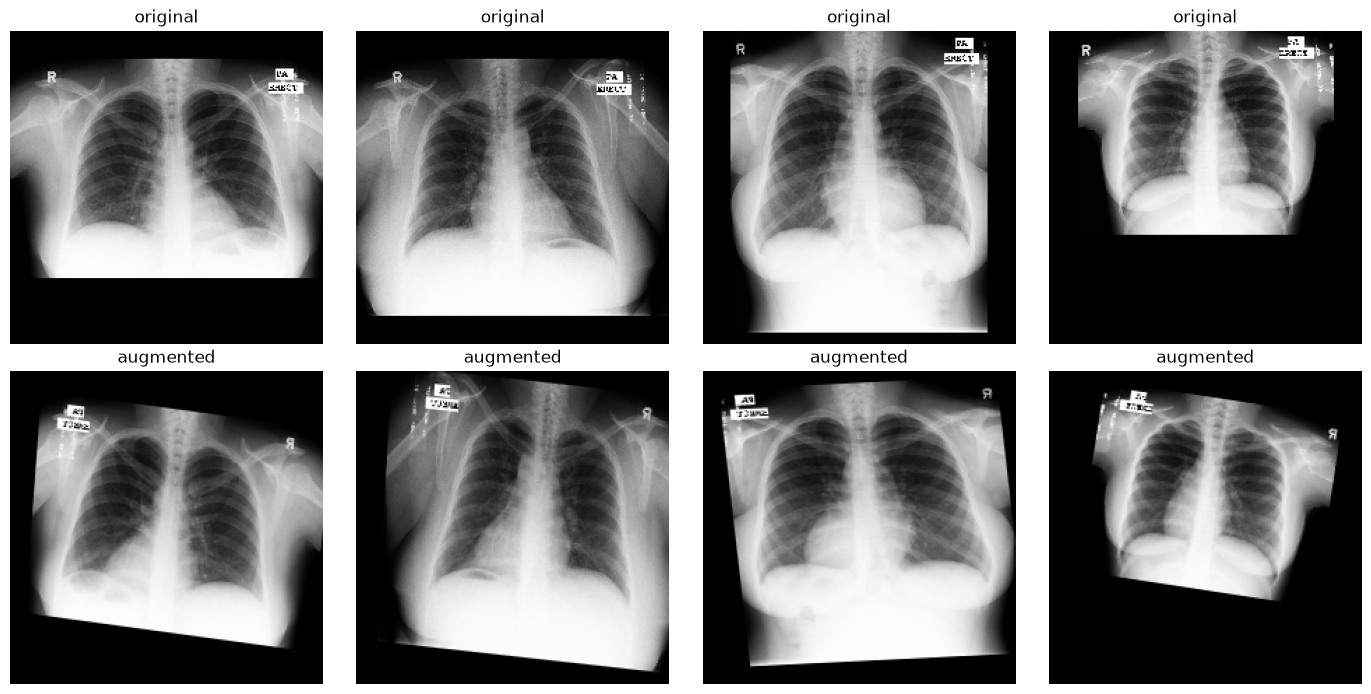

In [5]:
from radharmony.dataset import RadiologyTransform2D

aug = (
    RadiologyTransform2D(img_size=224, output_keys={"img", "cls"})
    .with_flip(spatial_axis=1, prob=1.0)  # left-right flip
    .with_affine(  # rotate + shift + zoom in one interpolation step
        rotate_range=(0.17,), translate_range=(15, 15), scale_range=(0.1, 0.1), prob=1.0
    )
    .with_intensity_jitter(shift=0.1, scale=0.1, prob=1.0)  # brightness / contrast
    .get_transform()
)

# Build a second dataset that applies the augmentation as its transform.
aug_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR, output_cls=True, cache_dir=None, transform=aug
).get_datasets()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j in range(4):
    axes[0, j].imshow(full_ds[j]["img"].float().squeeze(), cmap="gray")
    axes[0, j].set_title("original")
    axes[1, j].imshow(aug_ds[j]["img"].float().squeeze(), cmap="gray")
    axes[1, j].set_title("augmented")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Exploring datasets visually

RadHarmony also ships a small web app for browsing datasets without writing code: pick a dataset, point it at an image directory, and step through samples with masks and boxes overlaid. A sidebar toggles augmentations live and copies the matching transform code, so it pairs naturally with the augmentation builder above.

**Locally**, from the repository root:

```bash
python app.py          # or: uv run python app.py
```

Then open http://localhost:7860.

**On a remote machine** (e.g. a GPU server), run the app there and forward its port to your laptop. See the [App Guide](https://f10409.github.io/RadHarmony/app.html) for the full walkthrough.

**Datathon26** To use [RadHarmony Visualizer](https://a4422218c7d592ce06.gradio.live), you need the following information:

1. Base image directory:
/mnt/NAS4/projects/Montgomery-CXR/MontgomerySet/CXR_png
2. Mask output dir (required for output_mask):
/mnt/NAS4/projects/Montgomery-CXR/MontgomerySet/Mask_output

## 4. Segmentation masks and bounding boxes

So far each sample carried a single classification label (is a finding present?). Here the extra outputs are **spatial**.

A **segmentation mask** marks which pixels belong to a region, such as the lungs: a second image the same size as the X-ray.

The Montgomery set ships hand-drawn lung outlines, enabled with `output_mask=True`. It stores separate left and right outlines, which RadHarmony fuses into one mask file, so it needs an output directory (`mask_output_dir`); fusing runs once and is reused on later runs.

In [6]:
# Enable masks for this section by rebuilding the dataset with output_mask=True.
mask_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    output_cls=True,
    output_mask=True,
    mask_output_dir="./cache/montgomery_masks",  # fused masks are written here once
).get_datasets()

s = mask_ds[0]
print("Keys :", list(s.keys()))
print("img  :", tuple(s["img"].shape))
print(
    "mask :",
    tuple(s["mask"].shape),
    " (same size as the image; 1 = lung, 0 = background)",
)

Fusing lung masks: 100%|██████████| 138/138 [00:00<00:00, 13345.95it/s]


Keys : ['img', 'cls', 'mask']
img  : (1, 224, 224)
mask : (1, 224, 224)  (same size as the image; 1 = lung, 0 = background)


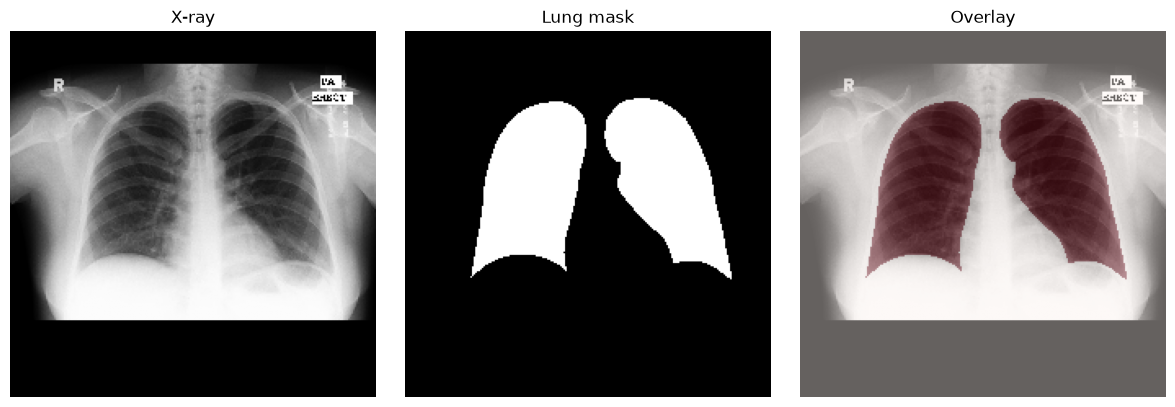

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
img = s["img"].float().squeeze()
mask = s["mask"].float().squeeze()

axes[0].imshow(img, cmap="gray")
axes[0].set_title("X-ray")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Lung mask")
axes[2].imshow(img, cmap="gray")
axes[2].imshow(mask, alpha=0.4, cmap="Reds")
axes[2].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Bounding boxes

A mask marks every pixel of a region; a **bounding box** marks a rectangle around a finding, how most detection datasets annotate abnormalities. Enable boxes with `output_bbox=True`.

VinDr-CXR ships radiologist-drawn boxes, each stored normalized:

> `[y_min, y_max, x_min, x_max]`

After loading they are relative to the 224×224 image, so multiplying by its size gives pixel positions.

VinDr-CXR images are DICOM files hosted on PhysioNet.

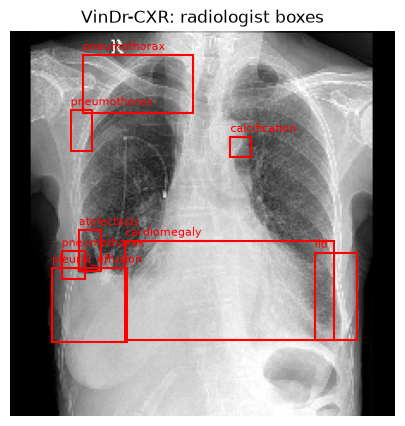

In [8]:
from radharmony.harmonizer import VinDrCXRTestHarmonizer
from radharmony.dataset import VinDrCXRTestDataset
import matplotlib.patches as patches

# VINDR_ROOT = "/mnt/NAS4/datasets/external/VinDr-CXR/physionet.org/files/vindr-cxr/1.0.0"
# VINDR_DIR = VINDR_ROOT + "/test/"
# VINDR_CSV = VINDR_ROOT + "/annotations/image_labels_test.csv"
# VINDR_BBOX = VINDR_ROOT + "/annotations/annotations_test.csv"

# Harmonize (reads the CSVs only, so it is fast), then keep a few images with boxes.
vindr_df = VinDrCXRTestHarmonizer(
    csv_path=VINDR_CSV, bbox_csv_path=VINDR_BBOX, base_image_dir=VINDR_DIR
).harmonize()
has_box = vindr_df["bbox"].apply(lambda b: isinstance(b, list) and len(b) > 0)
subset = vindr_df[has_box].head(3)

bbox_ds = VinDrCXRTestDataset(
    base_image_dir=VINDR_DIR, harmonized_df=subset, output_bbox=True, cache_dir=None
)
s = bbox_ds.get_datasets()[0]

img = s["img"].float().squeeze()
size = img.shape[0]  # 224
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img, cmap="gray")
for (y0, y1, x0, x1), name in zip(s["bbox"].float().tolist(), s["bbox_labels"]):
    ax.add_patch(
        patches.Rectangle(
            (x0 * size, y0 * size),
            (x1 - x0) * size,
            (y1 - y0) * size,
            fill=False,
            edgecolor="red",
            linewidth=1.5,
        )
    )
    ax.text(x0 * size, y0 * size - 3, name, color="red", fontsize=8)
ax.set_title("VinDr-CXR: radiologist boxes")
ax.axis("off")
plt.show()

## 5. Visual question answering

Some datasets pair each image with **text**. In a **visual question answering (VQA)** dataset, each image comes with a natural-language *question* and its *answer*:

> *"Is there a pleural effusion?"*  →  *"No"*

RadHarmony exposes these through the **same dataset interface**; only the keys in the returned sample change.

The example uses **VQA-RAD**: 315 radiology images (chest X-ray, CT, MRI) with 2,248 clinician-authored question-answer pairs.

In [9]:
from radharmony.dataset import VQARadDataset

# Point at the image folder; the QA JSON is found automatically beside it.
# VQA_RAD_DIR = "/mnt/NAS4/datasets/external/VQA-RAD/VQA_RAD Image Folder"

vqa = VQARadDataset(
    base_image_dir=VQA_RAD_DIR,
    output_question_type=True,  # also return each question's category
    cache_dir=None,
)

# No n_splits -> one dataset over every (image, question) pair.
qa = vqa.get_datasets()
print(f"Question-answer samples: {len(qa)}")

Question-answer samples: 2248


Indexing returns a sample dictionary, just as before, but now it carries **text** fields instead of a `cls` tensor:

- `img`: the image tensor, loaded and resized like any other dataset.
- `question` / `answer`: the question and its reference answer, as strings.
- `question_type`: the question category, which VQA-RAD gives as a short code.

The codes say what the question asks about: `PRES` (presence), `ABN` (abnormality), `MODALITY` (imaging type), `POS` (position), `ORGAN`, `PLANE`, `SIZE`, and `COLOR`.

In [10]:
sample = qa[0]

print("Keys     :", list(sample.keys()))
print("Image    :", tuple(sample["img"].shape), " (channels, height, width)")
print("Question :", sample["question"])
print("Answer   :", sample["answer"])
print("Type     :", sample["question_type"])

Keys     : ['img', 'question', 'answer', 'patient_id', 'study_id', 'question_id', 'question_type', 'img_transforms']
Image    : (3, 224, 224)  (channels, height, width)
Question : Are regions of the brain infarcted?
Answer   : Yes
Type     : PRES


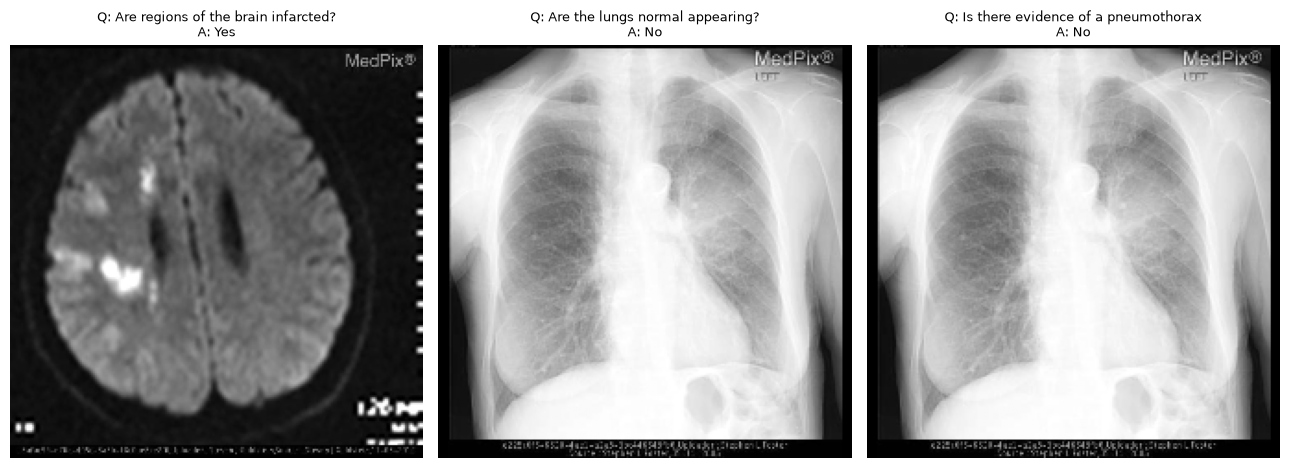

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, i in zip(axes, range(3)):
    s = qa[i]
    # VQA-RAD images are 3-channel; show one channel like the other examples.
    img = s["img"].float()
    img2d = img[0] if img.shape[0] > 1 else img.squeeze()
    ax.imshow(img2d, cmap="gray")
    ax.set_title(f"Q: {s['question']}\nA: {s['answer']}", fontsize=9, wrap=True)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Using a dataset with a `DataLoader`

Models train on **batches** (small groups of samples processed together) rather than one image at a time. PyTorch's `DataLoader` batches and shuffles samples between passes; since a RadHarmony dataset is a standard PyTorch dataset, it plugs in directly with no adapter code.

This is also where the train/validation split happens. `get_datasets(n_splits=5)`:

- splits **by patient** (no patient in both sets),
- holds out `1/n_splits` for validation (so `n_splits=5` gives an 80/20 split),
- seeds the partition with `random_state` (default `56`) for reproducibility.

For full k-fold cross-validation use `ds.get_folds(n_splits=5)`.

In [12]:
from torch.utils.data import DataLoader

# Split now: 4/5 of the patients for training, 1/5 held out for validation.
train_ds, val_ds = ds.get_datasets(n_splits=5)
print(f"Training images  : {len(train_ds)}")
print(f"Validation images: {len(val_ds)}")

loader = DataLoader(train_ds, batch_size=8, shuffle=True)

# Grab the first batch and see the shapes.
batch = next(iter(loader))
print("Images in one batch :", tuple(batch["img"].shape), " (batch, channels, H, W)")
print("Labels in one batch :", tuple(batch["cls"].shape))

Training images  : 110
Validation images: 28
Images in one batch : (8, 1, 224, 224)  (batch, channels, H, W)
Labels in one batch : (8, 1)


The leading `8` is the batch size: eight X-rays grouped together. This `batch`
dictionary is the input a model's training loop expects. Beyond this point the
workflow is standard PyTorch; RadHarmony's role is complete once the data is in
this form.

### Combining datasets for multi-dataset training

Because every dataset exposes the same sample schema, datasets from different sources can be pooled with PyTorch's `ConcatDataset` and trained through a single `DataLoader`. Supervised training just needs a shared label.

Here we pool SIIM-ACR and VinDr-CXR (both DICOM) on **pneumothorax**. SIIM is pneumothorax-only already; VinDr-CXR carries 28 findings, so we keep just its `pneumothorax` column to line the two label vectors up. Each sample then yields `cls = [pneumothorax]`, and the single loader batches across both.

In [13]:
from torch.utils.data import ConcatDataset
from radharmony.dataset import SIIMACRPTXDataset
from radharmony.harmonizer import SIIMACRPTXHarmonizer

# SIIM_DIR = "/mnt/NAS3/datasets/external/SIIM_ACR_Pneumothorax/dicom-images-train/"
# SIIM_CSV = "/mnt/NAS3/datasets/external/SIIM_ACR_Pneumothorax/train-rle.csv"

# Harmonize both (a slice of each keeps the demo quick). VINDR_CSV / VINDR_DIR
# were defined in Section 4.
print("Harmonizing SIIM Dataset")
siim_df = (
    SIIMACRPTXHarmonizer(csv_path=SIIM_CSV, dicom_dir=SIIM_DIR).harmonize().head(50)
)
print("Harmonizing VinDr Dataset")
vindr_df = (
    VinDrCXRTestHarmonizer(csv_path=VINDR_CSV, base_image_dir=VINDR_DIR)
    .harmonize()
    .head(50)
)

siim_ds = SIIMACRPTXDataset(
    base_image_dir=SIIM_DIR, harmonized_df=siim_df, output_cls=True, cache_dir=None
).get_datasets()

vindr = VinDrCXRTestDataset(
    base_image_dir=VINDR_DIR, harmonized_df=vindr_df, output_cls=True, cache_dir=None
)
vindr.LABEL_COLS = ["pneumothorax"]  # keep only the shared label, so cls lines up
vindr_ds = vindr.get_datasets()

# Both now yield cls = [pneumothorax], so they pool into one trainable stream.
pooled = ConcatDataset([siim_ds, vindr_ds])
print(f"SIIM: {len(siim_ds)}  +  VinDr: {len(vindr_ds)}  =  {len(pooled)} images")
print(
    "Pneumothorax-positive rows  ->  "
    f"SIIM: {int(siim_df['pneumothorax'].sum())}, VinDr: {int(vindr_df['pneumothorax'].sum())}"
)

multi_loader = DataLoader(pooled, batch_size=8, shuffle=True)
batch = next(iter(multi_loader))
print(
    "Combined batch :",
    tuple(batch["img"].shape),
    tuple(batch["cls"].shape),
    " (img: B, C, H, W ; cls: B, 1)",
)

Harmonizing SIIM Dataset
Harmonizing VinDr Dataset
SIIM: 50  +  VinDr: 50  =  100 images
Pneumothorax-positive rows  ->  SIIM: 33, VinDr: 2
Combined batch : (8, 1, 224, 224) (8, 1)  (img: B, C, H, W ; cls: B, 1)


## 7. The dataset registry

RadHarmony maintains a **registry** that maps a short string name to each dataset class. A dataset can then be selected from a config file or UI instead of a hard-coded `import`, with no class names to memorize.

In [14]:
from radharmony.registry import list_datasets, resolve_dataset

names = list_datasets()
print(f"{len(names)} datasets available:\n")
for n in names:
    print(" ", n)

64 datasets available:

  brax
  brax_png
  chestxray14
  chestxray14_bbox
  chestxray14_test
  chestxray14_train
  chexlocalize
  chexpert
  chexpert_plus
  chexpert_train
  chexpert_valid
  ct_rate
  emory_chorus
  emory_cxr
  gemex_vqa
  mimic_cxr
  mimic_cxr_jpg
  mimic_cxr_jpg_test
  mimic_ext_cxr_qba
  montgomery_cxr
  ms_cxr
  ms_cxr_t
  openi_cxr
  padchest
  radchestct
  ranzcr_clip
  rexgradient
  rexgradient_test
  rexgradient_train
  rexgradient_valid
  roco
  rsna_2022_cervical_spine
  rsna_2022_cervical_spine_bbox
  rsna_2022_cervical_spine_test
  rsna_2022_cervical_spine_train
  rsna_2024_lumbar_spine
  rsna_2024_lumbar_spine_test
  rsna_2024_lumbar_spine_train
  rsna_abdominal_trauma_2023
  rsna_abdominal_trauma_2023_test
  rsna_abdominal_trauma_2023_train
  rsna_bone_age
  rsna_bone_age_train
  rsna_bone_age_val
  rsna_pe_detection
  rsna_pe_detection_test
  rsna_pe_detection_train
  rsna_pneumonia
  rsna_pneumonia_kaggle
  rsna_pneumonia_kaggle_test
  rsna_pneumonia_k

In [15]:
# Look up a class by its name and use it exactly like a direct import.
DatasetCls = resolve_dataset("montgomery_cxr")

ds = DatasetCls(base_image_dir=MONTGOMERY_DIR, output_cls=True)
train_ds, val_ds = ds.get_datasets(n_splits=5)
print("Loaded", DatasetCls.__name__, "→", len(train_ds), "train images")

Loaded MontgomeryCXRDataset → 110 train images


Switching to a different dataset, such as VinDr-CXR or MIMIC-CXR, requires only a
different name and image directory. The downstream code (the sample dictionary,
the `DataLoader`, and the training loop) remains unchanged. This uniformity
across datasets is the central design goal of RadHarmony.

## 8. The harmonized table

Constructing a dataset in §1 quietly ran a **harmonizer**: the per-dataset adapter
that reads the dataset's native metadata (e.g. annotations, image path) and returns one canonical
**harmonized DataFrame**, one row per image:

- always `patient_id`, `study_id`, `image_path`;
- plus whatever the dataset provides: label columns (here `tb`), and optionally
  `view_position`, `mask_path`, `bbox`, `report`.

`get_datasets()` turns each row into a sample dict. This shared schema is why the
same code runs on any dataset, and why `patient_id` can drive the patient-level
split. Here is Montgomery's native metadata, and the table the harmonizer builds from it:

In [16]:
# import os

# Montgomery's native metadata comes in two pieces (there is no single labels CSV):
#  - the filename encodes the ID and the TB label (trailing 0 = normal, 1 = TB)
#  - a ClinicalReadings/<name>.txt file holds the patient's sex, age, and report
CR_DIR = os.path.join(os.path.dirname(MONTGOMERY_DIR.rstrip("/")), "ClinicalReadings")
example = "MCUCXR_0001_0"
print("A native image filename:", example + ".png")
print("\nIts ClinicalReadings text file:")
print(open(os.path.join(CR_DIR, example + ".txt")).read())

# The harmonizer parses all of that into one canonical table (every RadHarmony
# harmonizer works this way). The dataset in Section 1 ran it for you; here we
# call it directly.
from radharmony.harmonizer import MontgomeryCXRHarmonizer

harmonized_df = MontgomeryCXRHarmonizer(base_dir=MONTGOMERY_DIR).harmonize()
print("One row per image :", harmonized_df.shape)
print("Canonical columns :", harmonized_df.columns.tolist())

# patient_id/study_id/image_path are always present; tuberculosis is the label; sex/age/
# report come from the ClinicalReadings file shown above.
harmonized_df.head()

A native image filename: MCUCXR_0001_0.png

Its ClinicalReadings text file:
Patient's Sex: F 
Patient's Age: 027Y
normal

One row per image : (138, 9)
Canonical columns : ['patient_id', 'study_id', 'image_path', 'report', 'tuberculosis', 'sex', 'age', 'mask_path_left', 'mask_path_right']


,patient_id,study_id,image_path,report,tuberculosis,sex,age,mask_path_left,mask_path_right
0,MCUCXR_0001,MCUCXR_0001,MCUCXR_0001_0.png,normal,0,F,27,../ManualMask/leftMask/MCUCXR_0001_0.png,../ManualMask/rightMask/MCUCXR_0001_0.png
1,MCUCXR_0002,MCUCXR_0002,MCUCXR_0002_0.png,normal,0,F,40,../ManualMask/leftMask/MCUCXR_0002_0.png,../ManualMask/rightMask/MCUCXR_0002_0.png
2,MCUCXR_0003,MCUCXR_0003,MCUCXR_0003_0.png,normal,0,F,21,../ManualMask/leftMask/MCUCXR_0003_0.png,../ManualMask/rightMask/MCUCXR_0003_0.png
3,MCUCXR_0004,MCUCXR_0004,MCUCXR_0004_0.png,normal,0,F,11,../ManualMask/leftMask/MCUCXR_0004_0.png,../ManualMask/rightMask/MCUCXR_0004_0.png
4,MCUCXR_0005,MCUCXR_0005,MCUCXR_0005_0.png,normal,0,M,33,../ManualMask/leftMask/MCUCXR_0005_0.png,../ManualMask/rightMask/MCUCXR_0005_0.png


RadHarmony offers two independent ways to avoid repeating work:

- **`harmonized_df=`** skips the parsing step: pass a harmonized DataFrame straight
  back and no CSV scan runs (save it with `to_csv` to reuse across sessions).
- **`cache_dir=`** caches the *preprocessed images*: MONAI writes each decoded,
  resized, normalized tensor there on the first pass and reloads it on later ones, so
  the image files are read and processed only once.

Because the table is just a DataFrame, you can also filter it first to run on any
subset you want (one label, one view, a demographic slice).

In [17]:
# A scratch folder where MONAI caches the preprocessed image tensors
# (PersistentDataset); safe to delete anytime, it is rebuilt on demand.
CACHE_DIR = "./cache/montgomery"

# Filter the harmonized table to a subset, then build a dataset from it directly.
tb_only = harmonized_df[harmonized_df["tuberculosis"] == 1]
print(f"Full cohort: {len(harmonized_df)}  ->  TB-positive subset: {len(tb_only)}")

subset_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    harmonized_df=tb_only,  # use this table as-is; no harmonizing, no CSV scan
    output_cls=True,
    cache_dir=CACHE_DIR,  # cache preprocessed images so later passes skip re-reading
)

# Everything downstream (get_datasets, splitting, DataLoader) works exactly the same.
built = subset_ds.get_datasets()
print("Images in subset dataset:", len(built))

Full cohort: 138  ->  TB-positive subset: 58
Images in subset dataset: 58


### Try it yourself: filter the harmonized table

The cell above kept only TB-positive studies. Since the harmonized table is an ordinary pandas DataFrame, you can slice it on any column the harmonizer produced, e.g. `tb` (0 or 1), `sex` (`"M"` or `"F"`), or `age` (an integer). Write a filter that keeps a subset of your choice, then build a dataset from it exactly as above; only the filter line changes.

In [18]:
# Keep female patients older than 50 (any boolean mask on the columns works).
subset = harmonized_df[(harmonized_df["sex"] == "F") & (harmonized_df["age"] > 50)]
print(f"Full cohort: {len(harmonized_df)}  ->  your subset: {len(subset)}")

# Same pattern as the cell above; only the filter changed.
my_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    harmonized_df=subset,
    output_cls=True,
    cache_dir=None,
).get_datasets()
print("Images in your subset dataset:", len(my_ds))

Full cohort: 138  ->  your subset: 17
Images in your subset dataset: 17


## Summary

The consistent workflow across all datasets is: specify an image directory, set
the required `output_*` flags, and call `get_datasets()` to obtain
PyTorch-ready data.

Full documentation: **[f10409.github.io/RadHarmony](https://f10409.github.io/RadHarmony)**